# 07 — Decision Trees

A decision tree is a flowchart the model writes for itself: "if area > 1500
and quality > 6 then price = $X". It's the most interpretable model in this
handbook — you can read the *exact* rule it learned — and the most prone to a
specific failure: **memorising the training set** if you let it grow
unchecked. Pruning is the cure, and the whole story of this notebook.

## What you'll be able to do after this notebook

1. Explain how a tree splits data and why (Gini vs entropy).
2. **Visualise** a fitted tree and read its rules directly.
3. Use **feature importance** to explain a tree (and know its limits).
4. Diagnose and fix **overfitting** with `max_depth`, `min_samples_leaf`, and
 cost‑complexity pruning (`ccp_alpha`).
5. Recognise the tree's blind spots — the failure cases at the end.

## The process

```mermaid
flowchart TD
 E["EDA: which features split the target cleanly?<br/><small> §2 correlation hint</small>"] --> D
 D["Fit a DEEP tree first<br/><small>let it overfit — establishes the ceiling</small>"] --> P
 P["Prune: tune max_depth / min_samples_leaf / ccp_alpha via CV"] --> I
 I["Read the tree + feature importances<br/><small>interpret</small>"] --> T
 T["Evaluate on held‑out test<br/><small> §5</small>"]
```

## 1. The idea, in plain language

A tree partitions the feature space into **axis‑aligned boxes**. At each step it
asks the single yes/no question that best separates the classes (or reduces
target variance for regression):

- "Is `GrLivArea > 1500`?" → split into two regions.
- In each region, ask the next best question: "Is `OverallQual > 6`?"
- Repeat until a stopping rule fires (pure leaves, max depth, min samples).

The prediction for a new row is the majority class (classification) or mean
target (regression) of the leaf it lands in.

**Why trees are special:**
- **Interpretable** — the rules are human‑readable.
- **Handle non‑linearity and interactions automatically** — no need to engineer
 $x^2$ or $x_1 \times x_2$.
- **Scale‑invariant** — splits compare a feature to a threshold; the scale
 doesn't matter (unlike kNN/SVM). **No scaling needed.**
- **Handle mixed types** — numeric and categorical (after encoding) coexist.

**The catch:** a single tree is a **high‑variance** model (§6.2). Let it
grow deep and it carves a separate leaf for nearly every training row — perfect
on train, fragile on test. This notebook is largely about *restraining* it.

## 2. Splitting criteria — Gini vs entropy

At every node the tree picks the feature+threshold that makes the child nodes
"purer" than the parent. "Purity" is measured by:

| Criterion | Formula (class probabilities $p_k$) | Intuition |
|---|---|---|
| **Gini impurity** | $1 - \sum_k p_k^2$ | chance a random label in the node is wrong |
| **Entropy** | $-\sum_k p_k \log p_k$ | "surprise"/information content |
| **MSE** (regression) | mean of $(y - \bar y_{leaf})^2$ | spread of target in the leaf |

Both Gini and entropy almost always pick the **same splits** — don't agonise
over the choice. (Gini is the default and slightly faster.)

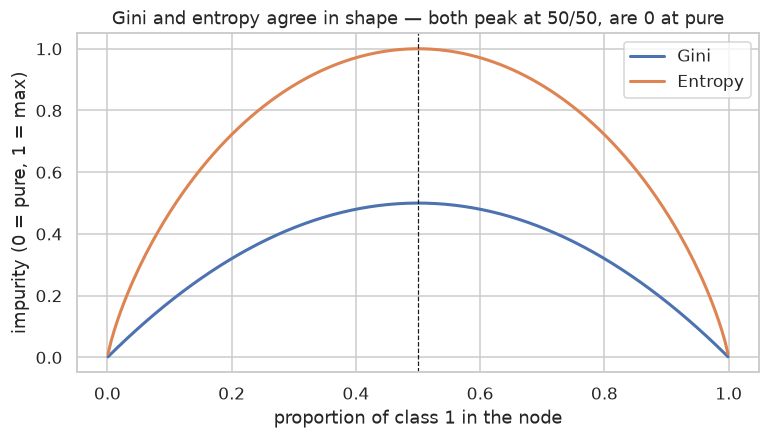

In [1]:
from setup import *

# Visualise Gini and entropy for a 2-class node as one class dominates.
p = np.linspace(0.001, 0.999, 200)
gini = 1 - (p**2 + (1-p)**2)
entropy = -(p*np.log2(p) + (1-p)*np.log2(1-p)) # scaled to [0,1]
plt.plot(p, gini, label="Gini", lw=2)
plt.plot(p, entropy, label="Entropy", lw=2)
plt.axvline(0.5, color="k", ls="--", lw=0.8)
plt.xlabel("proportion of class 1 in the node")
plt.ylabel("impurity (0 = pure, 1 = max)")
plt.title("Gini and entropy agree in shape — both peak at 50/50, are 0 at pure")
plt.legend(); plt.show()

Both curves peak when the node is 50/50 (maximum impurity) and hit 0 when the
node is pure. They're monotonic transforms of each other → they pick nearly
identical splits. Move on.

## 3. Worked example A — iris, and reading a tree

Let's fit a small tree on iris (petal measurements only, for clarity) and
*read* it. The visualisation is the point — this is the most interpretable model
in the handbook.

train accuracy: 0.981
test accuracy: 0.933


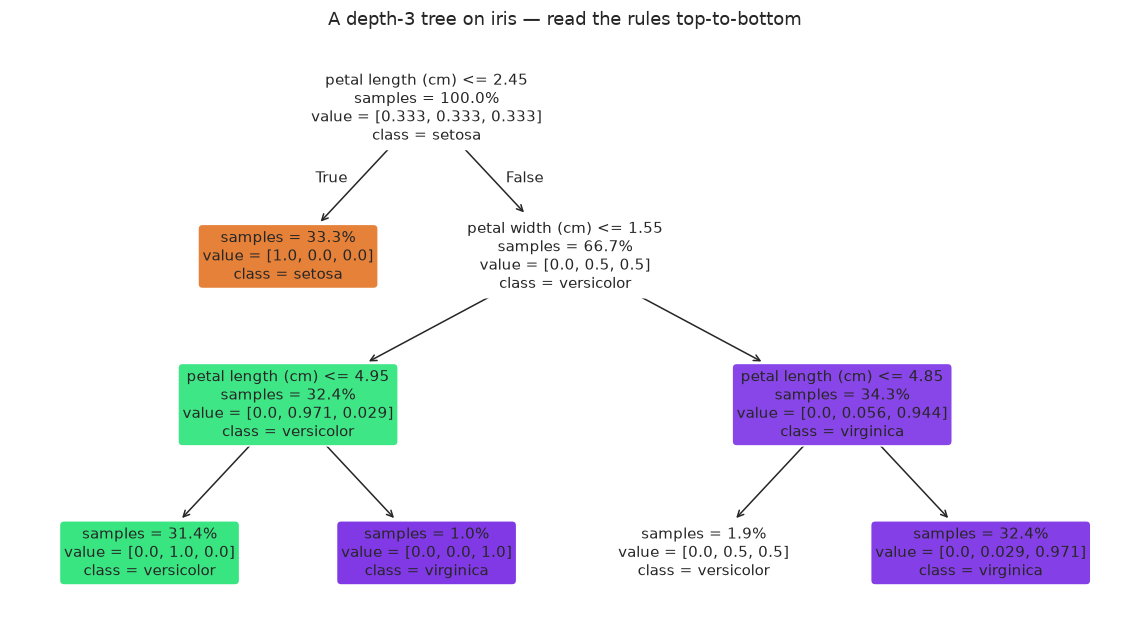

In [2]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]]
y = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)
print(f"train accuracy: {tree.score(X_tr, y_tr):.3f}")
print(f"test accuracy: {tree.score(X_te, y_te):.3f}")

plt.figure(figsize=(13, 7))
plot_tree(tree, feature_names=list(X.columns),
 class_names=list(iris.target_names), filled=True, rounded=True,
 fontsize=10, impurity=False, proportion=True)
plt.title("A depth‑3 tree on iris — read the rules top‑to‑bottom")
plt.show()

**How to read the tree:**
- **Top node ("petal length ≤ 2.45")** splits the whole dataset. Setosa (a
 small‑petal species) is fully separated in one cut — 33% of the data lands
 pure in the left leaf.
- **Right branch** then splits versicolor from virginica on petal width — a
 much harder boundary, with a few misclassifications.
- **Colours** = majority class in each node; darker = purer.
- **`samples`/`value`** = how many rows reach this node and how they're split
 across classes.

A domain expert can read this and immediately say whether it matches reality.
That's the tree's superpower.

### Decision boundary — axis‑aligned boxes

A tree's boundary is a staircase of axis‑aligned cuts. It **cannot** draw a
diagonal line — only a series of horizontal/vertical approximations. That's a
key limitation (and a hint to why forests and linear models sometimes win).

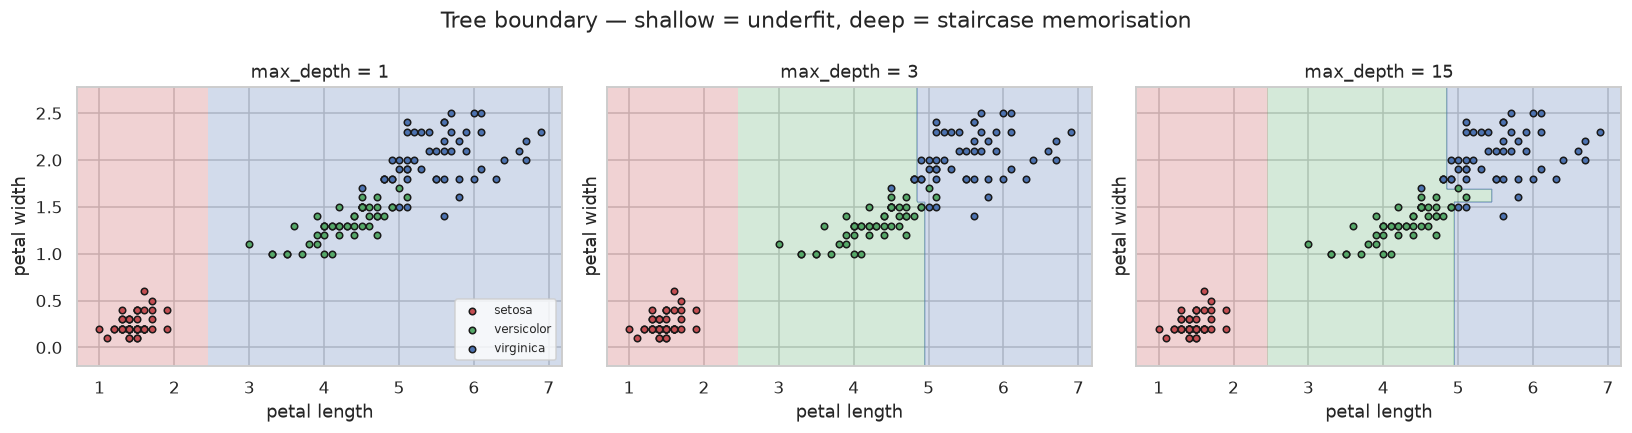

In [3]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#c44e52", "#55a868", "#4c72b0"])

def plot_tree_boundary(depth, ax):
    t = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_tr, y_tr)
    x_min, x_max = X.iloc[:,0].min()-0.3, X.iloc[:,0].max()+0.3
    y_min, y_max = X.iloc[:,1].min()-0.3, X.iloc[:,1].max()+0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap)
    for i, name in enumerate(iris.target_names):
        ax.scatter(X.iloc[y.values==i, 0], X.iloc[y.values==i, 1],
                   c=[cmap(i)], edgecolor="k", s=18, label=name)
    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("petal length"); ax.set_ylabel("petal width")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, d in zip(axes, [1, 3, 15]):
    plot_tree_boundary(d, ax)
axes[0].legend(fontsize=8, loc="lower right")
plt.suptitle("Tree boundary — shallow = underfit, deep = staircase memorisation")
plt.tight_layout(); plt.show()

Depth 1 is a single cut (underfit). Depth 3 captures the structure. Depth 15
carves a tight staircase around every training point — that's the
**overfitting signature**: the boundary is more about *the training samples*
than *the underlying pattern*.

## 4. Feature importance — and its limits

Trees compute **feature importance** = how much each feature reduced impurity
across all splits, weighted by how many rows each split covered.

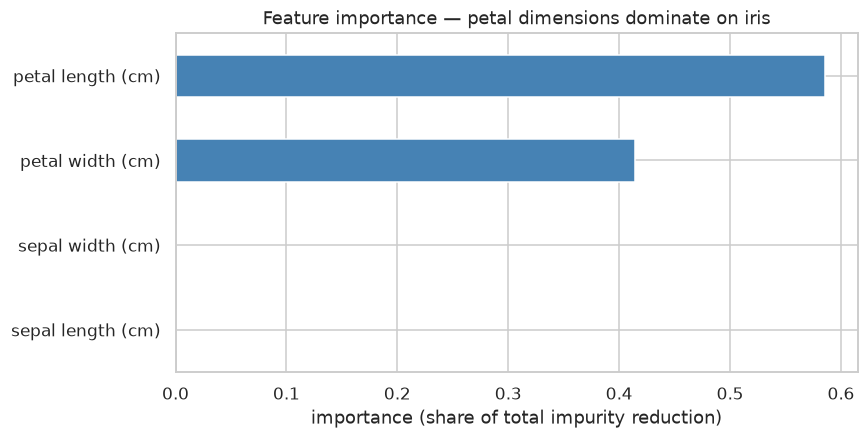

In [4]:
# Full iris (all 4 features), depth‑3 tree.
X_full = iris.data
tree_full = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_full, iris.target)
imp = pd.Series(tree_full.feature_importances_, index=X_full.columns).sort_values()
imp.plot(kind="barh", color="steelblue")
plt.title("Feature importance — petal dimensions dominate on iris")
plt.xlabel("importance (share of total impurity reduction)"); plt.show()

**Reading it:** petal length/width did all the work; sepal dimensions were
barely used. That matches the scatterplots — setosa is separable on petal
length alone.

> **Three limits of tree feature importance (important!):**
> 1. **Bias toward high‑cardinality features.** A feature with many possible
> split points gets more chances to look good, so importance is inflated for
> continuous/high‑cardinality columns. Use **permutation importance**
> (notebook 08) for a fairer measure.
> 2. **It's not directional.** Importance says "this feature matters", not
> "more of it raises the prediction". For direction, read the tree or use
> SHAP.
> 3. **It hides correlated features.** If two features carry the same
> information (§7.2 multicollinearity), the tree picks one at random and
> the other shows importance ≈ 0 — even though it's equally predictive.

## 5. Worked example B — Telco Churn (a real, messy dataset)

The CEO dataset is too small for meaningful trees (60 rows, ~5 per leaf). Let's
use **Telco Churn** (7k telecom customers) — a real binary classification
problem where trees are a sensible choice.

In [5]:
from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score

telco = fetch_openml(name="telco-customer-churn", version=1, as_frame=True, parser="auto").frame
# Drop any ID-like column if present (varies by OpenML version).
id_cols = [c for c in telco.columns if "id" in c.lower()]
if id_cols:
 telco = telco.drop(columns=id_cols)
# coerce TotalCharges to numeric (some blanks)
telco["TotalCharges"] = pd.to_numeric(telco["TotalCharges"], errors="coerce")
telco = telco.dropna()
X = telco.drop(columns=["Churn"])
y = (telco["Churn"] == "Yes").astype(int)
print(f"n = {len(telco)}, churn rate = {y.mean():.3f}")

cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = X.select_dtypes(include=np.number).columns.tolist()
pre = ColumnTransformer([
 ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
], remainder="passthrough") # trees don't need scaling — passthrough numerics

n = 7032, churn rate = 0.266


In [6]:
# A DEEP tree (no pruning) vs a shallow one (max_depth=4).
deep = Pipeline([("pre", pre),
 ("tree", DecisionTreeClassifier(random_state=42))])
shallow = Pipeline([("pre", pre),
 ("tree", DecisionTreeClassifier(max_depth=4, random_state=42))])

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
deep.fit(X_tr, y_tr); shallow.fit(X_tr, y_tr)

for name, m in [("deep (no pruning)", deep), ("shallow (max_depth=4)", shallow)]:
 auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
 tr = m.score(X_tr, y_tr)
 print(f"{name:<24} train acc = {tr:.3f} test AUC = {auc:.3f}")

deep (no pruning)        train acc = 0.999 test AUC = 0.654
shallow (max_depth=4)    train acc = 0.796 test AUC = 0.825


**The overfitting signature:** the deep tree hits near‑100% training accuracy
but a worse test AUC than the shallow tree. It memorised the training set. This
is exactly the bias–variance failure (§6.2) — high variance from too much
capacity.

## 6. Failure case — the unpruned tree (and the fix)

Let's make the overfitting visible and then fix it with **cost‑complexity
pruning** (`ccp_alpha`), the modern pruning knob in sklearn.

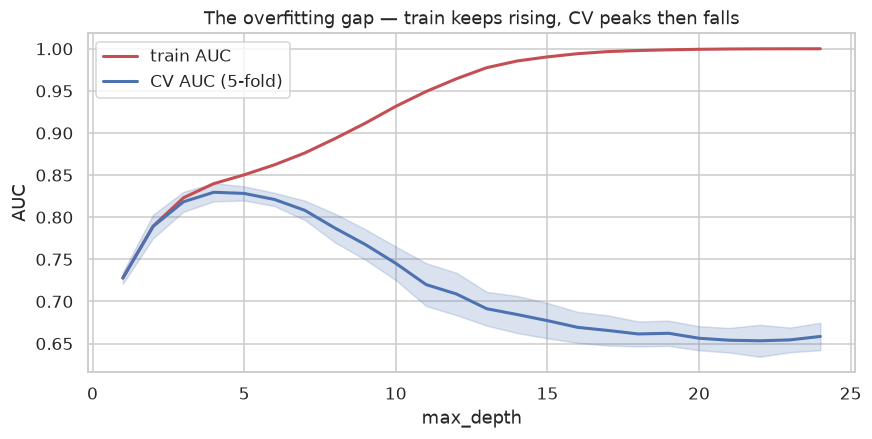

best max_depth by CV: 4


In [7]:
# Validation curve over max_depth — watch train/test diverge.
depths = np.arange(1, 25)
tr_scores, va_scores = validation_curve(
 Pipeline([("pre", pre), ("tree", DecisionTreeClassifier(random_state=42))]),
 X, y, param_name="tree__max_depth", param_range=depths,
 cv=5, scoring="roc_auc"
)

plt.figure(figsize=(9, 4))
# training accuracy proxy: refit each depth on all data
train_auc = []
for d in depths:
 m = Pipeline([("pre", pre),
 ("tree", DecisionTreeClassifier(max_depth=d, random_state=42))])
 m.fit(X, y)
 train_auc.append(roc_auc_score(y, m.predict_proba(X)[:, 1]))
plt.plot(depths, train_auc, label="train AUC", color="#c44e52", lw=2)
plt.plot(depths, va_scores.mean(axis=1), label="CV AUC (5-fold)", color="#4c72b0", lw=2)
plt.fill_between(depths, va_scores.mean(axis=1)-va_scores.std(axis=1),
 va_scores.mean(axis=1)+va_scores.std(axis=1), alpha=0.2, color="#4c72b0")
plt.xlabel("max_depth"); plt.ylabel("AUC")
plt.title("The overfitting gap — train keeps rising, CV peaks then falls")
plt.legend(); plt.show()
print(f"best max_depth by CV: {depths[va_scores.mean(axis=1).argmax()]}")

**The gap is the lesson.** Training AUC climbs monotonically toward 1.0 (the
tree can always memorise more). CV AUC peaks around depth 3–5 then *declines*
as the tree starts fitting noise. A practitioner who only looks at training
score picks depth 25 and ships a fragile model.

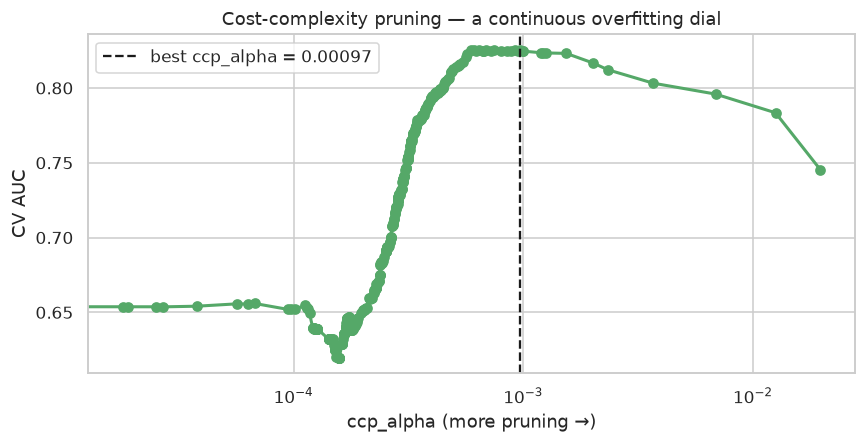

best ccp_alpha: 0.00097


In [8]:
# Cost-complexity pruning: a smarter, continuous knob.
# ccp_alpha penalises tree size; larger alpha = more pruning. Find alpha via CV.
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(pre.fit_transform(X_tr), y_tr)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Filter to a reasonable range (skip the trivial very last alpha that prunes everything)
ccp_alphas = ccp_alphas[:-1]

pruned_scores = []
for a in ccp_alphas:
 m = Pipeline([("pre", pre),
 ("tree", DecisionTreeClassifier(ccp_alpha=a, random_state=42))])
 s = cross_val_score(m, X, y, cv=5, scoring="roc_auc").mean()
 pruned_scores.append(s)

best_alpha = ccp_alphas[np.array(pruned_scores).argmax()]
plt.figure(figsize=(9, 4))
plt.plot(ccp_alphas, pruned_scores, "o-", color="#55a868", lw=2)
plt.axvline(best_alpha, color="k", ls="--", label=f"best ccp_alpha = {best_alpha:.5f}")
plt.xscale("log"); plt.xlabel("ccp_alpha (more pruning →)"); plt.ylabel("CV AUC")
plt.title("Cost‑complexity pruning — a continuous overfitting dial")
plt.legend(); plt.show()
print(f"best ccp_alpha: {best_alpha:.5f}")

**Three knobs to fight tree overfitting** (use one or more, tune via CV):
- **`max_depth`** — cap how deep the tree can grow. Blunt but effective.
- **`min_samples_leaf`** — require each leaf to have ≥ N rows. Stops single‑row
 leaves (the most extreme memorisation).
- **`ccp_alpha`** — cost‑complexity pruning. Continuous, principled; the
 modern default.

All three trade bias for variance (§6.2). The right combination is whatever
cross‑validation picks.

## 7. When a single tree fails — and what comes next

A single decision tree is rarely the best‑performing model on real data. Its
two structural weaknesses, both fixed by **random forests** (notebook 08):

| Weakness | Why it happens | Forest's fix |
|---|---|---|
| **High variance** | Small data changes → very different tree | **Bagging**: average many trees |
| **Axis‑aligned only** | Can't draw diagonal boundaries | Many random trees vote; boundary smooths |
| **Greedy, locally optimal splits** | Each split is myopic | **Random feature subsets** at each split |

> The single tree's value is **interpretability and as a building block**.
> Forests (08) and gradient boosting trade interpretability for accuracy by
> combining hundreds of trees. Read this notebook first; the rest builds on it.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Shipping an unpruned tree (§6).** Train ≈ 1.0, test much worse. Always
 prune (`max_depth` / `min_samples_leaf` / `ccp_alpha`) via CV.
2. **Trusting raw feature importance (§4).** It's biased toward high‑cardinality
 features and hides direction. Use permutation importance / SHAP for serious
 interpretation.
3. **Interpreting a single split as causal (§3).** "The tree split on income
 first, so income drives churn" — no, it means income *separates* churn.
 Trees find correlations, not causes.
4. **Expecting trees to extrapolate.** A tree predicts the leaf mean forever —
 it cannot trend upward outside the training range. Bad for time‑series
 forecasting.
5. **One‑hotting high‑cardinality categoricals.** Trees fragment the data
 across many sparse splits. Ordinal/target encoding often works better.
6. **Forgetting stratify on imbalanced targets.** A deep tree on rare‑class
 data can produce leaves with zero minority examples.

## Exercises

1. **Read a tree.** In §3, follow the path a *versicolor* flower with
 petal_length=4.5, petal_width=1.3 takes through the tree. Which leaf does it
 land in, and what's the predicted class?
2. **Pruning yourself.** On Telco, set `min_samples_leaf=100` and refit. How do
 train/test AUC change vs the deep tree? Why does capping leaf size help?
3. **Importance bias.** Add a column of random unique IDs to the Telco features
 and refit a deep tree. Does the ID column get high importance? Why is this
 the cardinality‑bias warning in action?
4. **No extrapolation.** Fit a `DecisionTreeRegressor` on `x = [1..50]`,
 `y = x` (a clean line). Predict at `x = 60`. What do you get, and why is
 this disqualifying for forecasting?
5. **Gini vs entropy.** On Telco, fit two trees — one `criterion="gini"`, one
 `"entropy"` — same depth. Compare their test AUC and feature importances.
 Are they meaningfully different?

<details><summary>Answers (click to expand)</summary>

```python
# 1: petal_length 4.5 > 2.45 -> right. petal_width 1.3 <= 1.75 -> left child.
# Then petal_length 4.5 <= 4.95 -> leaf, predicted = versicolor. (Exact path
# depends on the fitted thresholds — read your own tree's numbers.)

# 2: min_samples_leaf=100 caps each leaf at >=100 rows, preventing single-row
# memorisation. Train AUC drops, test AUC usually rises. It's a simpler
# alternative to ccp_alpha.

# 3
X_bad = X.copy(); X_bad["random_id"] = np.arange(len(X_bad))
# deep tree -> random_id gets nontrivial importance despite being pure noise.
# This is the cardinality-bias warning — many unique values = many split
# points = inflated importance. Use permutation importance instead.

# 4
from sklearn.tree import DecisionTreeRegressor
import numpy as np
r = DecisionTreeRegressor().fit(np.arange(1,51).reshape(-1,1), np.arange(1,51))
print(r.predict([[60]])) # -> ~50, the max leaf value. Cannot extrapolate.

# 5: Nearly identical — Gini and entropy pick essentially the same splits.
# A 4th decimal difference at most. Don't agonise over the criterion.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §3
 (correlation ≠ causation, relevant to interpreting splits), §6 (bias/variance
 — pruning is the variance dial), §7.2 (multicollinearity & feature
 importance).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 9 —
 <https://bradleyboehmke.github.io/HOML/decision-trees.html>.
- scikit‑learn — *Decision Trees* user guide (incl. ccp_alpha):
 <https://scikit-learn.org/stable/modules/tree.html>.
- Breiman et al. (1984), *Classification and Regression Trees* — the original
 CART text.